In [ ]:
# Simulated Data Engine & Preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (15, 6)

def generate_power_grid_data(days=365):
    """Generates realistic hourly power grid load data (in MW) with injected anomalies."""
    np.random.seed(42)
    start_date = datetime(2025, 1, 1)
    date_list = [start_date + timedelta(hours=x) for x in range(days * 24)]
    
    base_load = 5000 
    data = []
    
    for i, dt in enumerate(date_list):
        daily_pattern = 1200 * np.sin(2 * np.pi * dt.hour / 24 - np.pi/2)
        weekly_pattern = 500 * np.sin(2 * np.pi * dt.weekday() / 7)
        seasonal_pattern = 800 * np.sin(2 * np.pi * dt.timetuple().tm_yday / 365)
        noise = np.random.normal(0, 150)
        
        total_load = base_load + daily_pattern + weekly_pattern + seasonal_pattern + noise
        
        if i in [1200, 3400, 5200]:  
            total_load -= 2500  
        elif i in [2100, 6800]:
            total_load += 3000  

        data.append([dt, total_load])
        
    df = pd.DataFrame(data, columns=['Datetime', 'Grid_Load_MW'])
    df.set_index('Datetime', inplace=True)
    return df

df = generate_power_grid_data(days=365)
print(df.head())

                     Grid_Load_MW
Datetime                         
2025-01-01 00:00:00   4375.741764
2025-01-01 01:00:00   4321.384004
2025-01-01 02:00:00   4559.157437
2025-01-01 03:00:00   4881.160982
2025-01-01 04:00:00   4866.111635


In [ ]:
# Feature Engineering: Time Series Transformations
def extract_time_features(data):
    """Generates temporal and historical lag features for the regressor."""
    df_feat = data.copy()
    
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['dayofyear'] = df_feat.index.dayofyear
    
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24.0)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24.0)
    
    df_feat['lag_1h'] = df_feat['Grid_Load_MW'].shift(1)
    df_feat['lag_2h'] = df_feat['Grid_Load_MW'].shift(2)
    df_feat['lag_24h'] = df_feat['Grid_Load_MW'].shift(24)  
    df_feat['lag_1w'] = df_feat['Grid_Load_MW'].shift(168) 
    
    df_feat.dropna(inplace=True)
    return df_feat

df_engineered = extract_time_features(df)

In [3]:
# Train-Test Split
split_idx = int(len(df_engineered) * 0.8)

train_data = df_engineered.iloc[:split_idx]
test_data = df_engineered.iloc[split_idx:]

features = ['hour_sin', 'hour_cos', 'dayofweek', 'month', 'dayofyear', 'lag_1h', 'lag_2h', 'lag_24h', 'lag_1w']
target = 'Grid_Load_MW'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Training shape: (6873, 9), Testing shape: (1719, 9)


In [4]:
# Training the Forecasting Module
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forecaster = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

forecaster.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

test_data = test_data.copy()  
test_data['Predicted_Load_MW'] = forecaster.predict(X_test)

mae = mean_absolute_error(y_test, test_data['Predicted_Load_MW'])
rmse = np.sqrt(mean_squared_error(y_test, test_data['Predicted_Load_MW']))
r2 = r2_score(y_test, test_data['Predicted_Load_MW'])

print(f"--- Forecaster Performance ---")
print(f"MAE: {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"R² Score: {r2:.4f}")

--- Forecaster Performance ---
MAE: 166.76 MW
RMSE: 212.48 MW
R² Score: 0.9516


In [5]:
# Advanced Anomaly Detection Engine
from sklearn.ensemble import IsolationForest

test_data['Residual'] = (test_data['Grid_Load_MW'] - test_data['Predicted_Load_MW']).abs()

anomaly_features = ['Grid_Load_MW', 'Residual']
iso_forest = IsolationForest(contamination=0.01, random_state=42) 

test_data['Anomaly_Class'] = iso_forest.fit_predict(test_data[anomaly_features])

test_data['Is_Anomaly'] = test_data['Anomaly_Class'].apply(lambda x: True if x == -1 else False)

detected_anomalies = test_data[test_data['Is_Anomaly'] == True]
print(f"Total anomalies flagged in evaluation set: {len(detected_anomalies)}")

Total anomalies flagged in evaluation set: 18


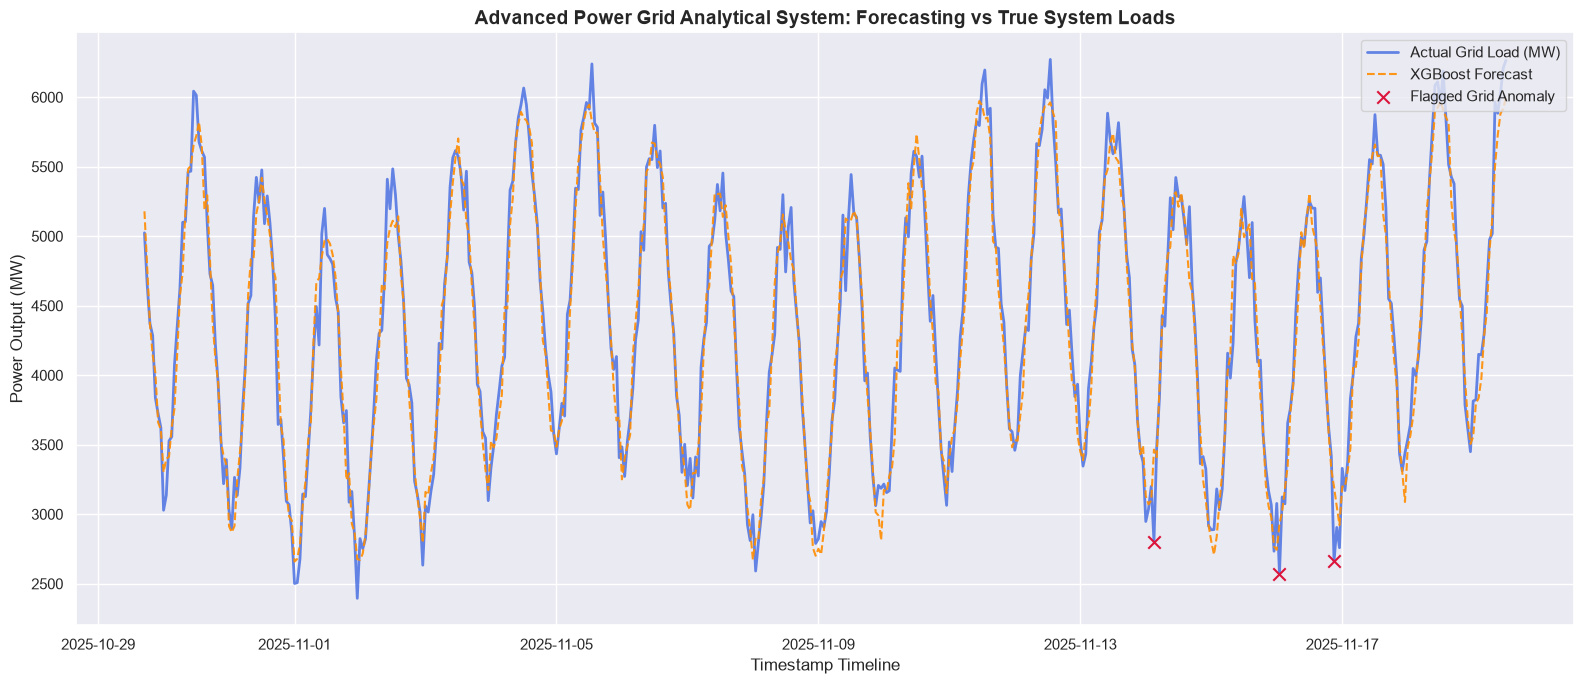

In [6]:
# Visulalization Generation
plt.figure(figsize=(16, 7))

# Plot actual vs predicted timelines for a window segment
plot_range = test_data.iloc[200:700]  # Grab a subset slice for visualization resolution
plt.plot(plot_range.index, plot_range['Grid_Load_MW'], label='Actual Grid Load (MW)', color='royalblue', alpha=0.8, linewidth=2)
plt.plot(plot_range.index, plot_range['Predicted_Load_MW'], label='XGBoost Forecast', color='darkorange', linestyle='--', alpha=0.9)

# Overlay identified anomalies within that frame
subset_anomalies = plot_range[plot_range['Is_Anomaly'] == True]
plt.scatter(subset_anomalies.index, subset_anomalies['Grid_Load_MW'], color='crimson', label='Flagged Grid Anomaly', zorder=5, s=80, marker='x')

plt.title('Advanced Power Grid Analytical System: Forecasting vs True System Loads', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp Timeline', fontsize=12)
plt.ylabel('Power Output (MW)', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()